# Machine Learning - Session 4

## Regularization with `Ridge`

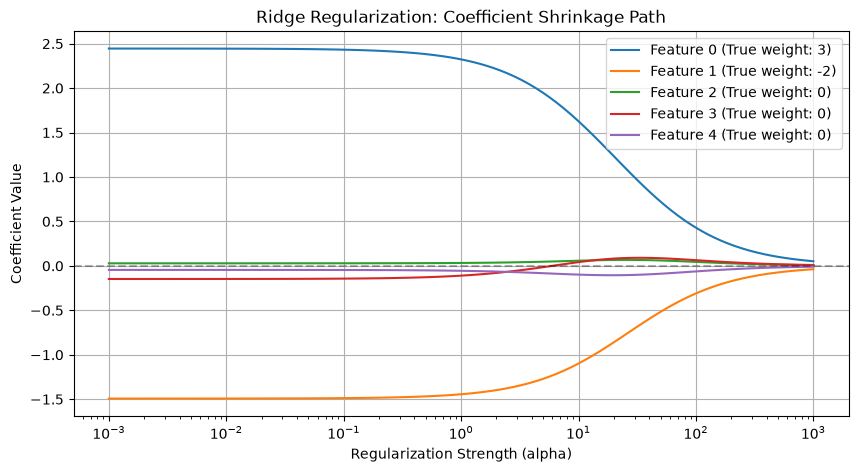

OLS L2 Norm (||w||^2): 8.2301
Ridge (alpha=1000.0) L2 Norm: 0.0044


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data (5 features)
n_samples, n_features = 20, 5
rng = np.random.RandomState(42)
X = rng.randn(n_samples, n_features)
# True relationship: features 0 and 1 drive y; features 2-4 are pure noise
y = 3.0 * X[:, 0] - 2.0 * X[:, 1] + rng.randn(n_samples) * 0.5

# 2. Scale features (critical for regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit OLS as a baseline
ols = LinearRegression().fit(X_scaled, y)

# 4. Sweep alpha across 6 orders of magnitude
alphas = np.logspace(-3, 3, 100)
coefs = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_scaled, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# 5. Plot the Ridge Coefficient Path
plt.figure(figsize=(10, 5))
for i in range(n_features):
    plt.plot(alphas, coefs[:, i], label=f"Feature {i} (True weight: {[3, -2, 0, 0, 0][i]})")

plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Ridge Regularization: Coefficient Shrinkage Path")
plt.xlabel("Regularization Strength (alpha)")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(True)
plt.show()

# 6. Compare norm of weights (L2 norm) between OLS and high-alpha Ridge
print(f"OLS L2 Norm (||w||^2): {np.sum(ols.coef_**2):.4f}")

idx = -1  # Last alpha in the list (1000.0)
print(f"Ridge (alpha={alphas[idx]:.1f}) L2 Norm: {np.sum(coefs[idx]**2):.4f}")